In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error|

load dataset

In [4]:

df = pd.read_csv('/content/exchange_rate.csv')

In [5]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [7]:
df.columns

Index(['date', 'Ex_rate'], dtype='object')

In [8]:
df.shape

(7588, 2)

In [11]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


check missing values


In [12]:
df.isnull().sum()

,0
date,0
Ex_rate,0


In [13]:
if df.index.name == 'date':
    df.reset_index(inplace=True)

df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')

df.set_index('date', inplace=True)

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


plot time series

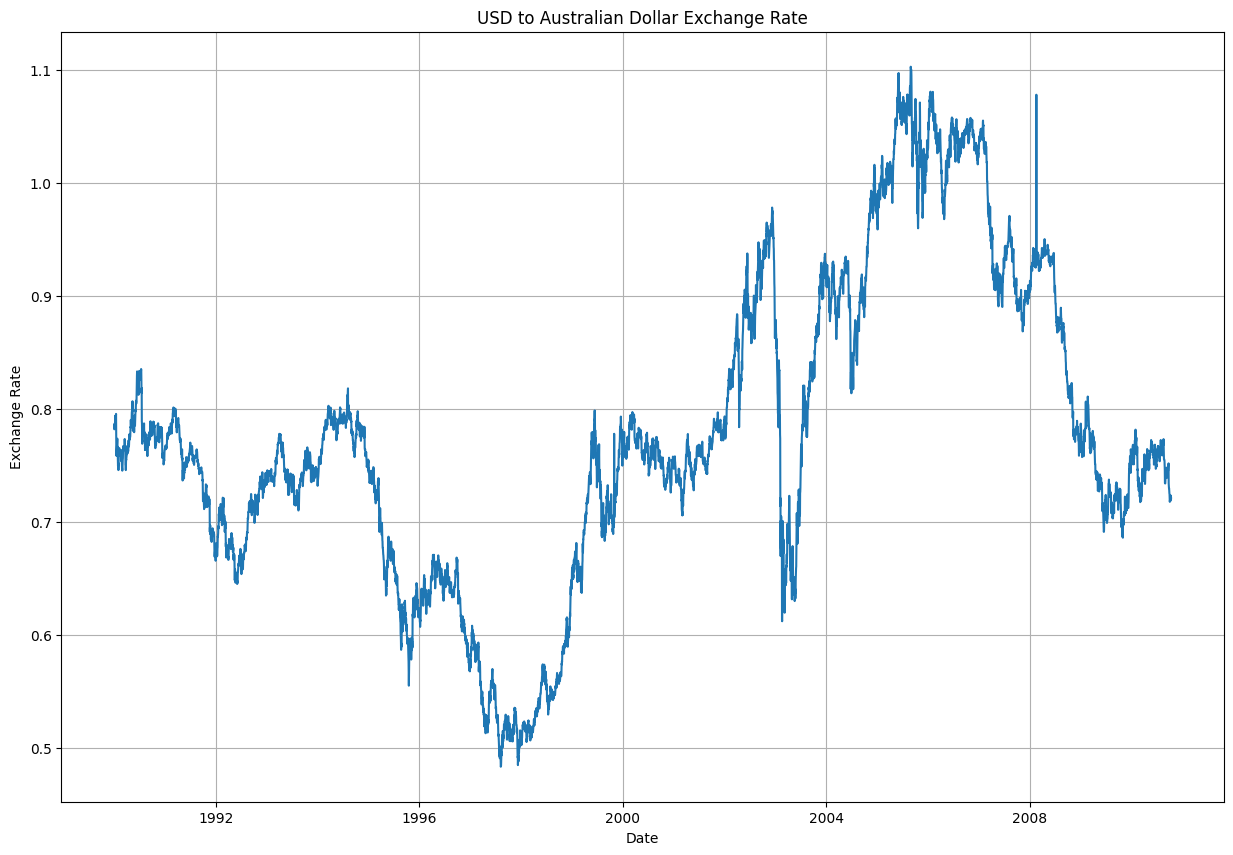

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
plt.plot(df['Ex_rate'])
plt.title("USD to Australian Dollar Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.show()

statinarity plot

In [17]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Ex_rate'])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -1.6649941807382342
p-value : 0.4492327353597477
1% : -3.4312123140180137
5% : -2.861921078147796
10% : -2.5669728434336108


differencing

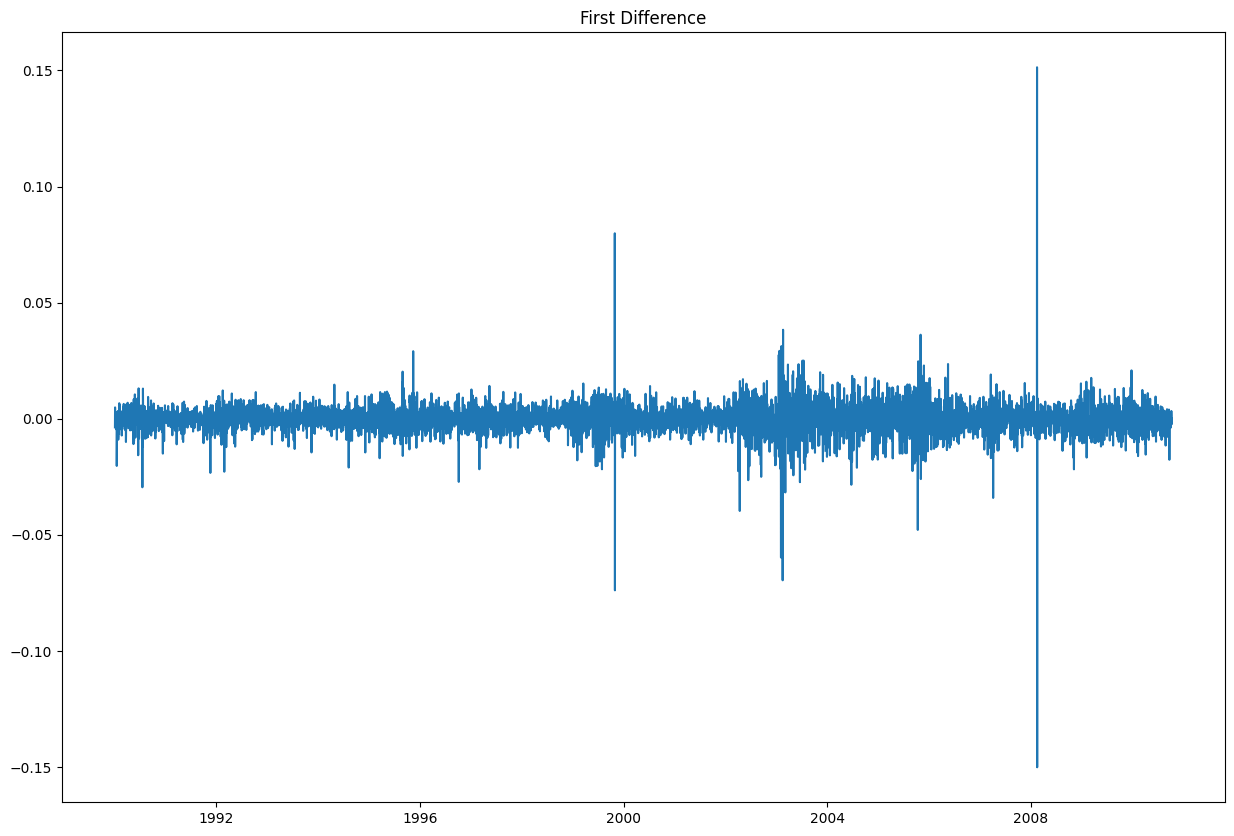

In [19]:
diff = df['Ex_rate'].diff().dropna()

plt.figure(figsize=(15,10))
plt.plot(diff)
plt.title("First Difference")
plt.show()

adf agian

In [20]:
result = adfuller(diff)

print(result[1])

0.0


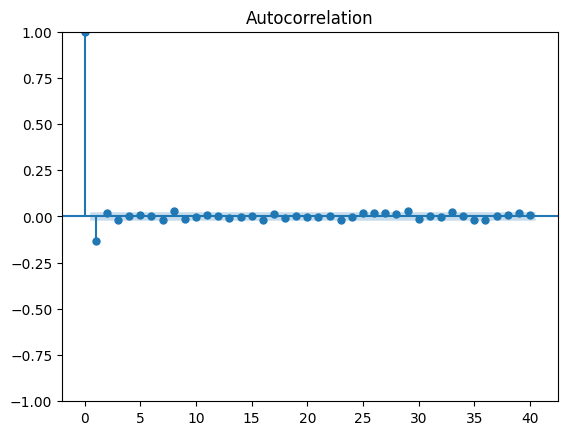

In [22]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(diff,lags=40)
plt.show()

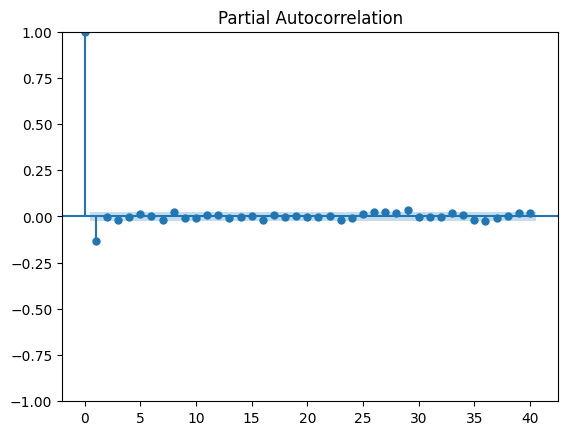

In [24]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(diff,lags=40)
plt.show()

In [25]:
train = df.iloc[:-365]
test = df.iloc[-365:]

ARIMA model

model fitting

In [27]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Ex_rate'],
              order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7223
Model:                 ARIMA(1, 1, 1)   Log Likelihood               26630.933
Date:                Mon, 31 Aug 2026   AIC                         -53255.866
Time:                        10:51:59   BIC                         -53235.211
Sample:                    01-01-1990   HQIC                        -53248.760
                         - 10-10-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1206      0.046     -2.620      0.009      -0.211      -0.030
ma.L1         -0.0119      0.046     -0.257      0.797      -0.102       0.079
sigma2       3.67e-05   1.04e-07    354.163      0.0

diagostics

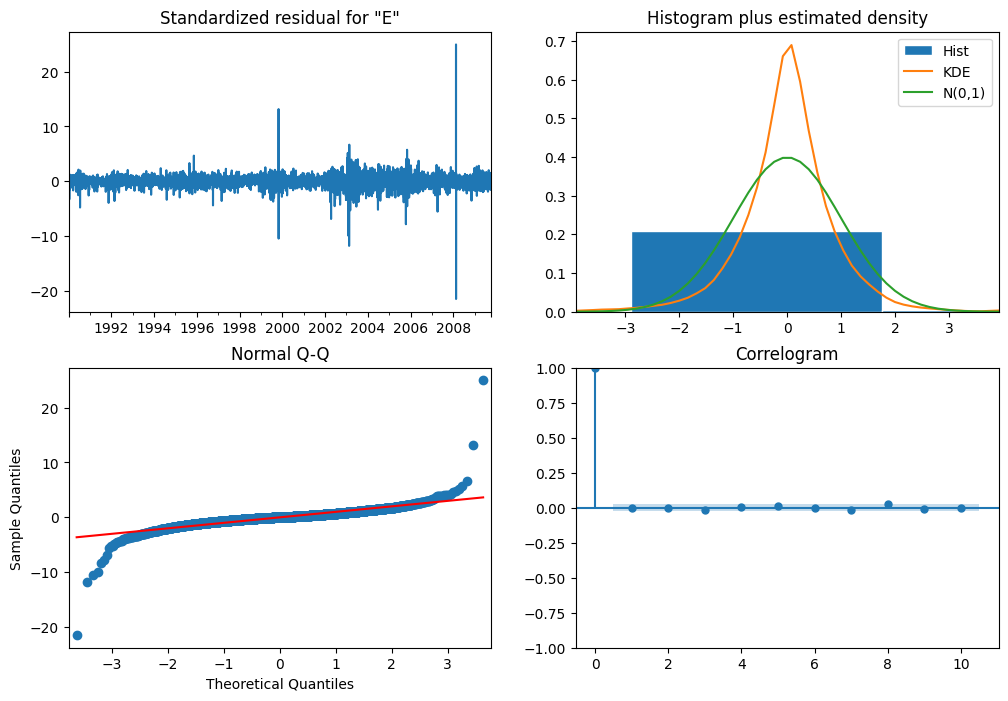

In [28]:
model_fit.plot_diagnostics(figsize=(12,8))
plt.show()

forecast

In [29]:
forecast = model_fit.forecast(steps=len(test))

plot forecast

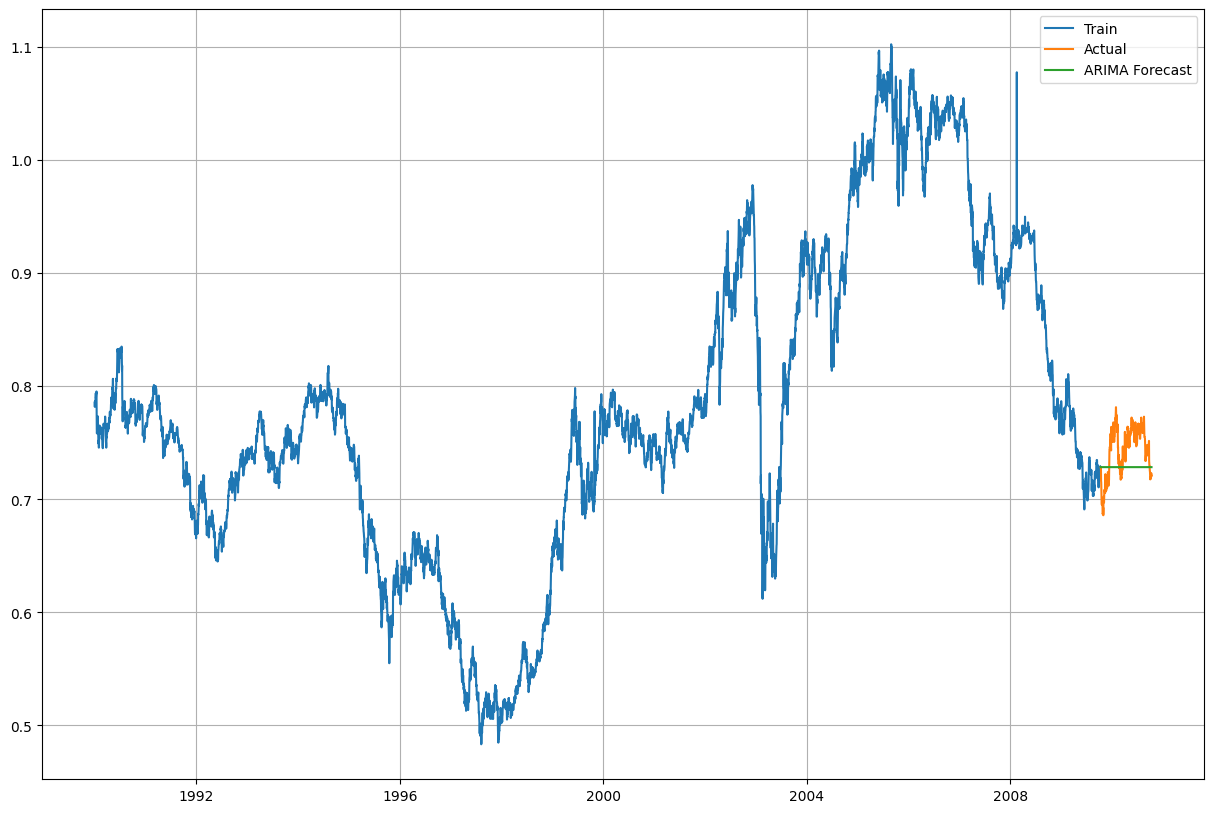

In [30]:
plt.figure(figsize=(15,10))

plt.plot(train.index,
         train['Ex_rate'],
         label='Train')

plt.plot(test.index,
         test['Ex_rate'],
         label='Actual')

plt.plot(test.index,
         forecast,
         label='ARIMA Forecast')

plt.legend()
plt.grid(True)
plt.show()

In [32]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
exp_model = ExponentialSmoothing(
                train['Ex_rate'],
                trend='add',
                seasonal=None)

exp_fit = exp_model.fit()

exp_forecast = exp_fit.forecast(len(test))

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


plot

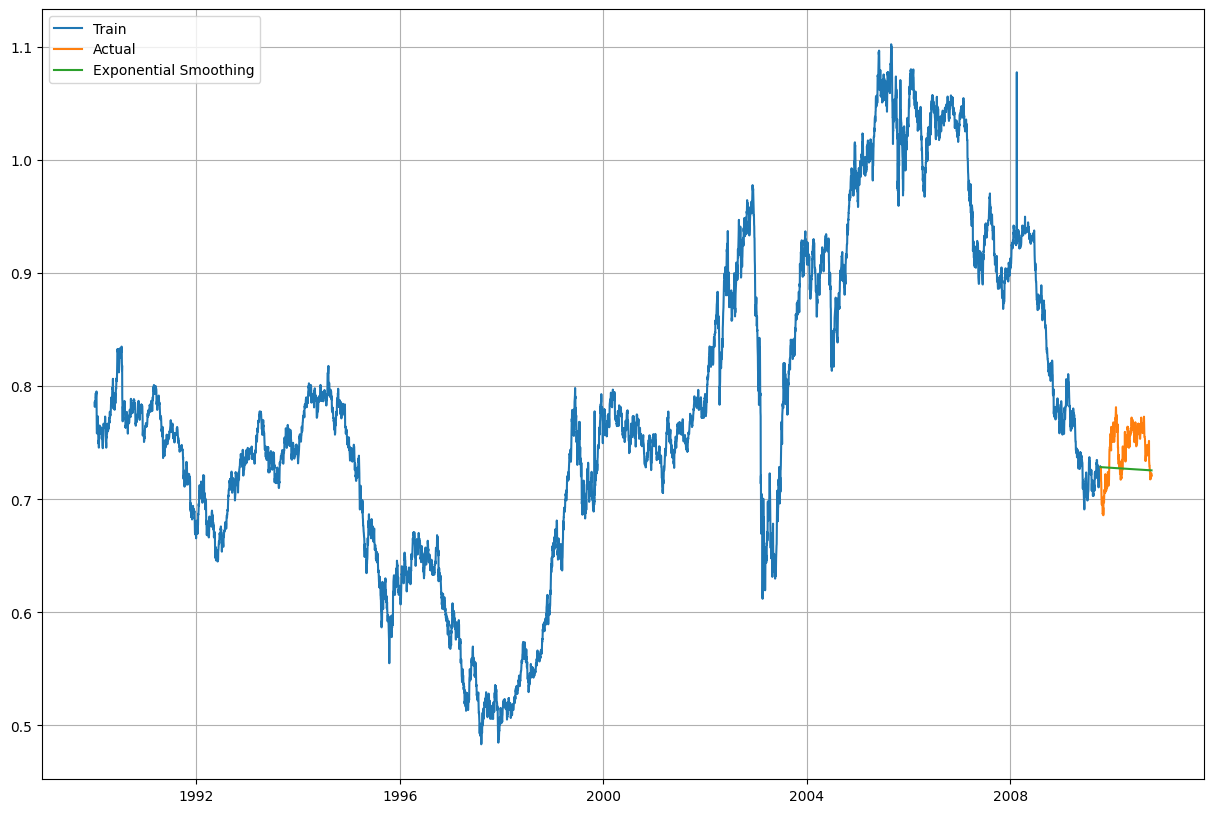

In [33]:
plt.figure(figsize=(15,10))

plt.plot(train.index,
         train['Ex_rate'],
         label='Train')

plt.plot(test.index,
         test['Ex_rate'],
         label='Actual')

plt.plot(test.index,
         exp_forecast,
         label='Exponential Smoothing')

plt.legend()
plt.grid(True)
plt.show()

evaluation

MAE

In [35]:
from sklearn.metrics import mean_absolute_error

arima_mae = mean_absolute_error(test['Ex_rate'],
                                forecast)

exp_mae = mean_absolute_error(test['Ex_rate'],
                              exp_forecast)

RMSE

In [39]:
import numpy as np
from sklearn.metrics import mean_squared_error
arima_rmse = np.sqrt(mean_squared_error(test['Ex_rate'],
                                        forecast))

exp_rmse = np.sqrt(mean_squared_error(test['Ex_rate'],
                                      exp_forecast))

MAPE

In [41]:
 def mape(actual,pred):

    return np.mean(
        np.abs((actual-pred)/actual))*100

arima_mape = mape(test['Ex_rate'],forecast)

exp_mape = mape(test['Ex_rate'],exp_forecast)

comparison table

In [40]:
comparison = pd.DataFrame({

    'Model':['ARIMA',
             'Exponential Smoothing'],

    'MAE':[arima_mae,
           exp_mae],

    'RMSE':[arima_rmse,
            exp_rmse],

    'MAPE':[arima_mape,
            exp_mape]

})

comparison


,Model,MAE,RMSE,MAPE
0,ARIMA,0.023388,0.026229,3.122357
1,Exponential Smoothing,0.024420,0.027393,3.257919


visualization


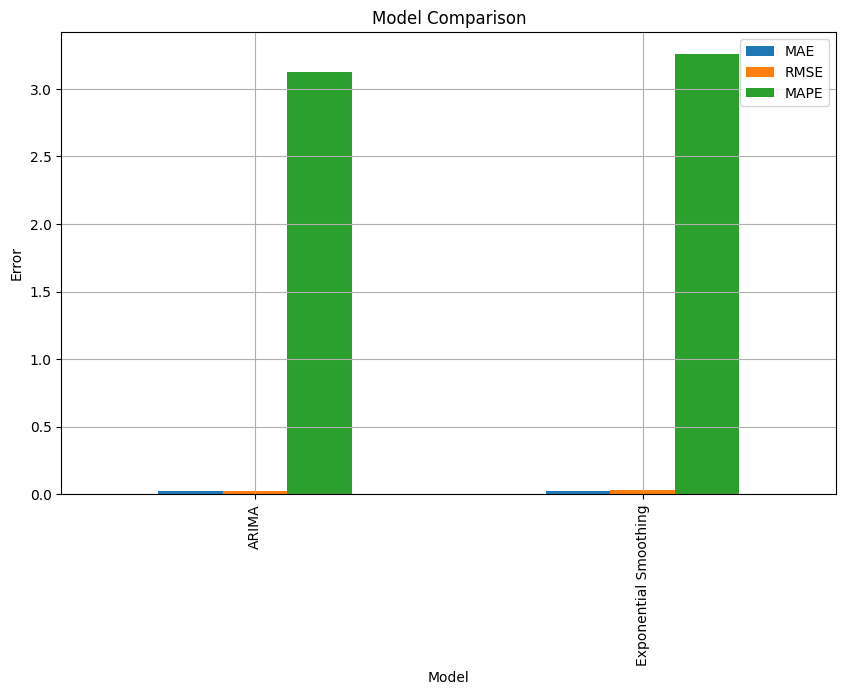

In [43]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6))

plt.ylabel("Error")
plt.title("Model Comparison")
plt.grid(True)
plt.show()